In [3]:
import imports
import split, model, weights, balance_train

In [4]:
import numpy as np

X = np.load("input/X.npy")
y = np.load("input/y.npy")

print(X.shape)  # (N, 90, 1)
print(y.shape)  # (N,)


(36543, 90, 1)
(36543,)


In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split.stratified_split(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (23387, 90, 1) (23387,)
Val:   (5847, 90, 1) (5847,)
Test:  (7309, 90, 1) (7309,)


In [5]:
print("Train class distribution:", np.bincount(y_train.astype(int)))
print("Val class distribution:", np.bincount(y_val.astype(int)))
print("Test class distribution:", np.bincount(y_test.astype(int)))


Train class distribution: [23053   334]
Val class distribution: [5764   83]
Test class distribution: [7205  104]


In [6]:
print(y_train.shape)

(23387,)


In [6]:
import importlib
import model
importlib.reload(model)

<module 'model' from '/home/jupyter-22wh1a12a2/major_project/RNA/model.py'>

In [8]:
from model import build_model, compile_model

model1 = build_model()
model1 = compile_model(model1)

model1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 90, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 90, 32)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 90, 32)    │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 90, 32)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 90, 96)    │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 45, 96)    │          0 │ concatenate_1[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     41,216 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,017 (179.75 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
X_balanced, y_balanced = balance_train.balance_data(X_train, y_train, positive_factor=3, random_state=42)

In [21]:
print(y_train.dtype)
print(np.unique(y_train))

float32
[0. 1.]


In [10]:
print(np.bincount(y_train.astype(int)))
print(np.bincount(y_balanced.astype(int)))

[23053   334]
[1002 1002]


In [11]:
history = balance_train.train_model(model1, X_balanced, y_balanced, X_val, y_val)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6935 - pr_auc: 0.4830 - precision_1: 0.4961 - recall_1: 0.5653 - roc_auc: 0.4863
Epoch 1: val_pr_auc improved from None to 0.01420, saving model to output/rna_balanced.keras

Epoch 1: finished saving model to output/rna_balanced.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.6935 - pr_auc: 0.4941 - precision_1: 0.4930 - recall_1: 0.3892 - roc_auc: 0.4932 - val_loss: 0.6911 - val_pr_auc: 0.0142 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.6933 - pr_auc: 0.4851 - precision_1: 0.4634 - recall_1: 0.4299 - roc_auc: 0.4876
Epoch 2: val_pr_auc did not improve from 0.01420
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.6932 - pr_auc: 0.4954 - precision_1: 0.4885 - recall_1: 0.4222 - roc_auc: 0.4944 - val_loss: 0.6953 - val_pr_auc: 0.0142 - val_precision_1: 0.0142 - val_recall_1: 1.0000 - val_roc_auc: 0.

In [12]:
results = model1.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(results)

{'loss': 0.2941852807998657, 'pr_auc': 0.46593958139419556, 'precision_1': 0.08476104587316513, 'recall_1': 0.9038461446762085, 'roc_auc': 0.9540083408355713}


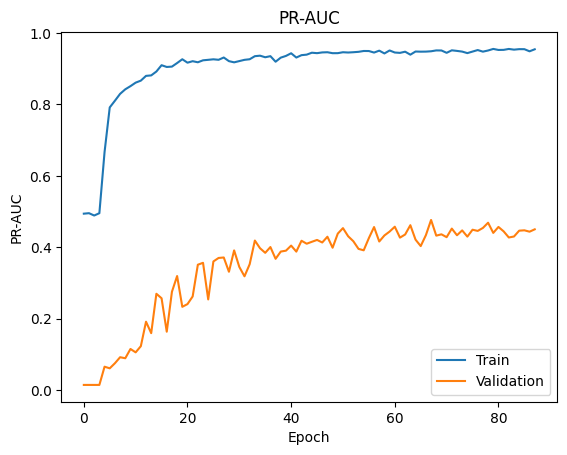

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['pr_auc'])
plt.plot(history.history['val_pr_auc'])
plt.title('PR-AUC')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend(['Train', 'Validation'])
plt.show()


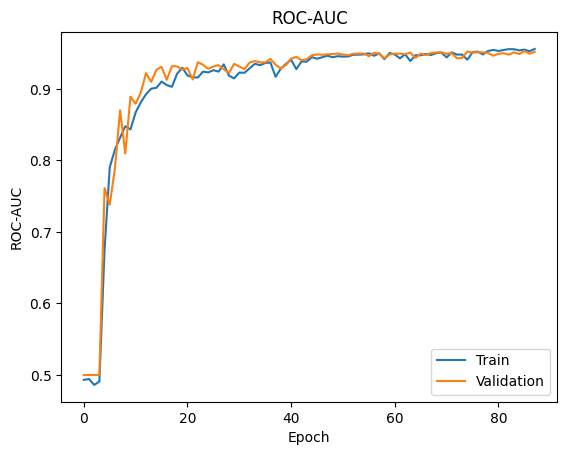

In [14]:
plt.plot(history.history['roc_auc'])
plt.plot(history.history['val_roc_auc'])
plt.title('ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend(['Train', 'Validation'])
plt.show()


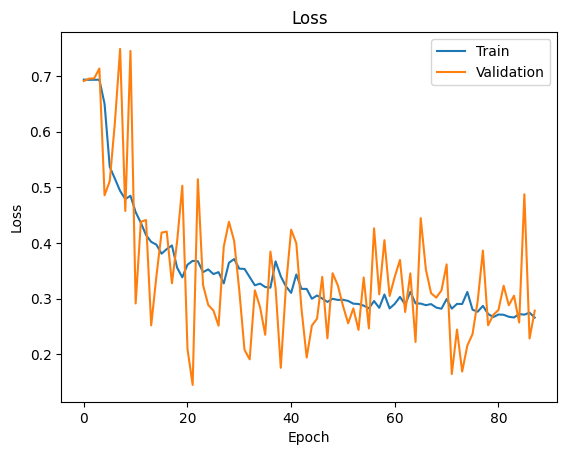

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [6]:
from tensorflow.keras.models import load_model
import numpy as np

model1 = load_model("output/rna_balanced.keras", compile=False)
predictions = model1.predict(X_test)  
predictions = predictions.flatten()    

predicted_labels = (predictions > 0.5).astype(int)
y_true = y_test.flatten().astype(int)

accuracy = (predicted_labels == y_true).mean()
print("Test Accuracy:", accuracy)

229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Test Accuracy: 0.859761937337529
